In [2]:
import yt
import numpy as np
#from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display

In [3]:
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [4]:
#path = "../Output_64_longrun/plt0????"
#path = "../Output_v2_64/plt0????"
#path = "../Output_12_shortrun/plt0????"
path = "../Output_64_n10000/plt?????"
dsLoad = AMReXDatasetSeries(path)

In [5]:
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2025-02-25 09:57:55,914 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-25 09:57:55,915 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-02-25 09:57:55,915 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-25 09:57:55,916 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-25 09:57:55,955 Parameters: current_time              = 3.55997053790648e-05
yt : [INFO     ] 2025-02-25 09:57:55,956 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-02-25 09:57:55,957 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-25 09:57:55,957 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-25 09:57:55,995 Parameters: current_time              = 7.11994107581296e-05
yt : [INFO     ] 2025-02-25 09:57:55,995 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-02-25 09:57:55,996 Parameters: domain_left_ed

In [6]:
def _relRef (field, data):
    av = data.ds.all_data().quantities.weighted_average_quantity("SCHf_Re", weight = ("index", "ones"))
    return data["SCHf_Re"]/av
for data in ds:
    data.add_field(("boxlib","SCHf_Re"), function=_relRef, sampling_type="local", units="dimensionless")

yt : [WARNING  ] 2025-02-25 09:58:35,531 Field ('boxlib', 'SCHf_Re') already exists. To override use `force_override=True`.



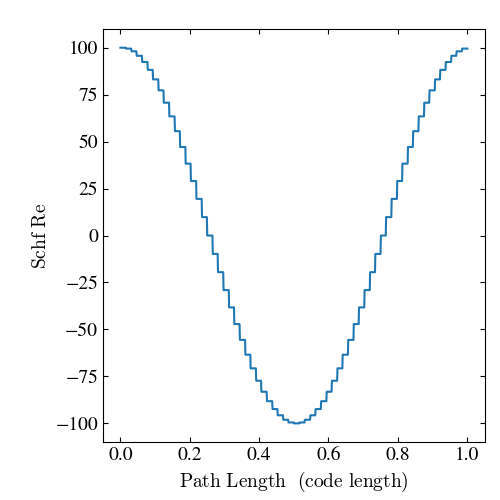

In [7]:
plot = yt.LinePlot(ds[0], "SCHf_Re", (0.0, 0.0, 0.0), (1.0, 0.0, 0.0), 1000)
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log("SCHf_Re", False)
#plot.show()
#plot.annotate_grids()

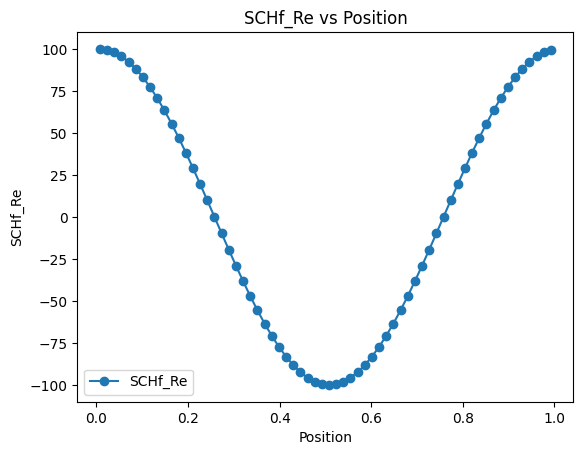

In [8]:
def extract_x_axis_arrays(AMReXDataset):
    ax = 0  # take a line cut along the x axis
    ray = AMReXDataset.ortho_ray(ax, (0.5, 0.5))  # taking a cut through the center of the y and z axes

    # Sort the ray values by 'x' so there are no discontinuities in the line plot
    srt = np.argsort(ray["index", "x"])
    return ray, srt

ray, srt = extract_x_axis_arrays(ds[0])
x = np.array(ray["index", "x"][srt])
y = np.array(ray['boxlib', 'SCHf_Re'][srt])
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the data
ax.plot(x, y, label="SCHf_Re", marker='o')

# Add labels and title
ax.set_xlabel("Position")
ax.set_ylabel("SCHf_Re")
ax.set_title("SCHf_Re vs Position")

# Add a legend
ax.legend()

# Show the plot
plt.show()

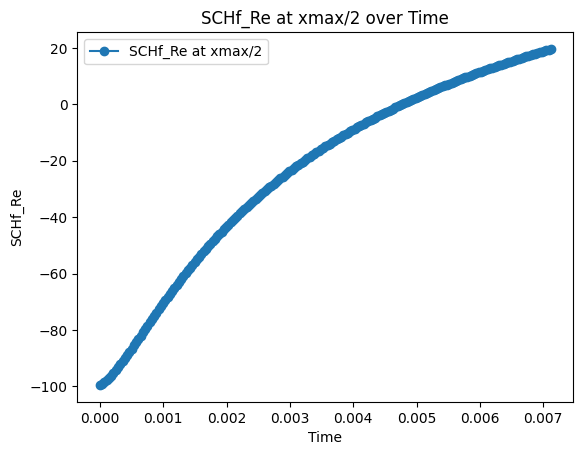

In [9]:
# Extract the x position at xmax/2
xmax = np.max(x)
x_half = xmax / 2

# Initialize empty lists to store the values of SCHf_Re at x_half and corresponding times
schf_re_values = []
times = []

# Loop through each dataset and extract the value of SCHf_Re at x_half
for data in ds:
    ray, srt = extract_x_axis_arrays(data)
    x_sorted = np.array(ray["index", "x"][srt])
    y_sorted = np.array(ray['boxlib', 'SCHf_Re'][srt])
    
    # Find the index of the closest x value to x_half
    idx = (np.abs(x_sorted - x_half)).argmin()
    
    # Append the corresponding SCHf_Re value and time to the lists
    schf_re_values.append(y_sorted[idx])
    times.append(data.current_time.value)

# Plot the values of SCHf_Re at x_half over time
fig, ax = plt.subplots()
ax.plot(times, schf_re_values, marker='o', linestyle='-', label="SCHf_Re at xmax/2")

# Add labels and title
ax.set_xlabel("Time")
ax.set_ylabel("SCHf_Re")
ax.set_title("SCHf_Re at xmax/2 over Time")

# Add a legend
ax.legend()

# Show the plot
plt.show()


0.15915494309189535
0.37843063633514534


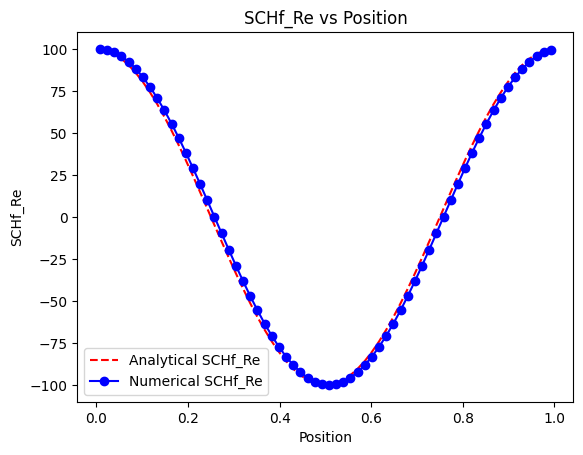

In [10]:
AMReXDataset = ds[0]
# Analytical solution
Lbox = AMReXDataset.domain_width[0].v  # Box length
SCH_k_mode = 1  # Adjust as needed
SCH_k = SCH_k_mode * 2.0 * np.pi / Lbox
print(1/SCH_k)
hbaroverm = 0.01917152  
omega = SCH_k * SCH_k * hbaroverm / 2.0  # Dispersion relation
print(omega)
SCH0 = 100.0  
time = AMReXDataset.current_time.value  

x = np.array(ray["index", "x"][srt])
analytic_re = SCH0 * np.cos(SCH_k * x - omega * time)

# Plot the analytical solution
fig, ax = plt.subplots()
ax.plot(x, analytic_re, label="Analytical SCHf_Re", linestyle='--', color='red')

# Plot the numerical solution
ax.plot(x, y, label="Numerical SCHf_Re", marker='o', color='blue')

# Add labels and title
ax.set_xlabel("Position")
ax.set_ylabel("SCHf_Re")
ax.set_title("SCHf_Re vs Position")

# Add a legend
ax.legend()

# Show the plot
plt.show()

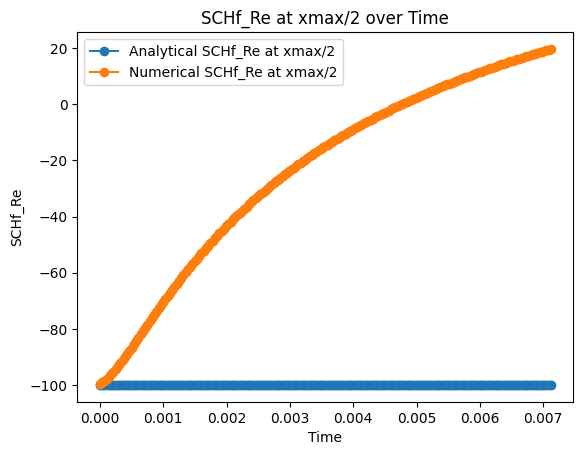

In [11]:
# Extract the x position at xmax/2
x_half = xmax / 2

# Initialize an empty list to store the analytical values of SCHf_Re at x_half over time
analytic_values = []

# Loop through each dataset and calculate the analytical value of SCHf_Re at x_half
for data in ds:
    time = data.current_time.value  # Get the current time
    analytic_value = SCH0 * np.cos(SCH_k * x_half - omega * time)
    analytic_values.append(analytic_value)

# Plot the analytical values of SCHf_Re at x_half over time
fig, ax = plt.subplots()
ax.plot(times, analytic_values, marker='o', linestyle='-', label="Analytical SCHf_Re at xmax/2")
ax.plot(times, schf_re_values, marker='o', linestyle='-', label="Numerical SCHf_Re at xmax/2")

# Add labels and title
ax.set_xlabel("Time")
ax.set_ylabel("SCHf_Re")
ax.set_title("SCHf_Re at xmax/2 over Time")

# Add a legend
ax.legend()

# Show the plot
plt.show()

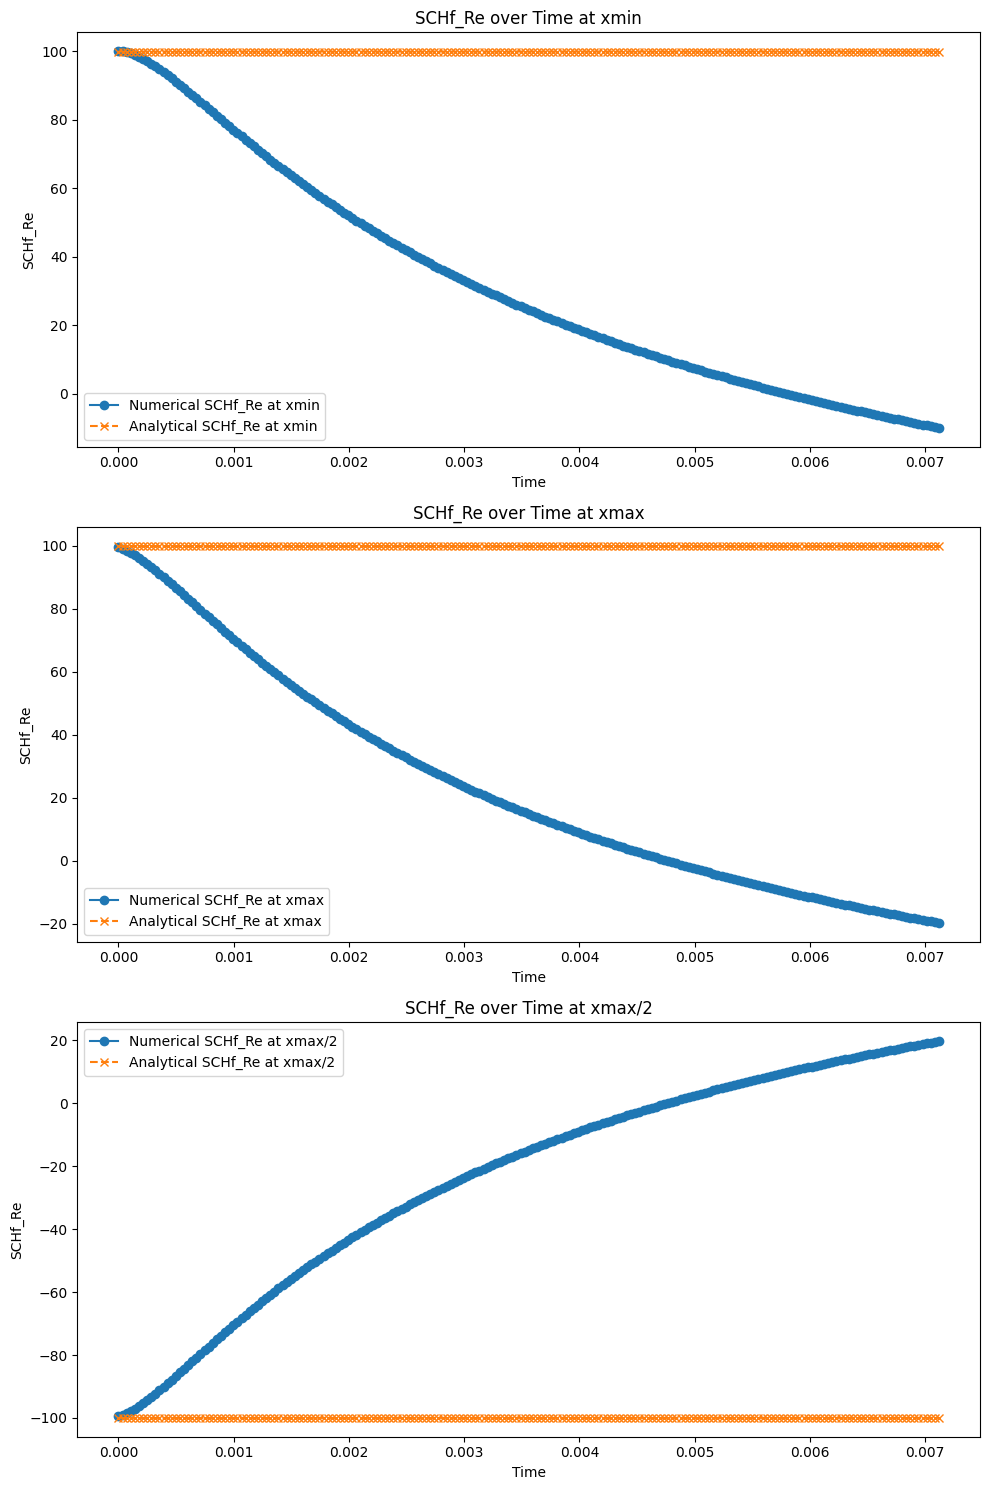

In [12]:
# Extract the x positions at xmin, xmax, and xmax/2
xmin = np.min(x)
xmax = np.max(x)
x_half = xmax / 2

# Initialize empty lists to store the values of SCHf_Re at xmin, xmax, and x_half and their analytical results
schf_re_values_xmin = []
schf_re_values_xmax = []
schf_re_values_x_half = []
analytic_values_xmin = []
analytic_values_xmax = []
analytic_values_x_half = []

# Loop through each dataset and extract the values of SCHf_Re at xmin, xmax, and x_half
for data in ds:
    ray, srt = extract_x_axis_arrays(data)
    x_sorted = np.array(ray["index", "x"][srt])
    y_sorted = np.array(ray['boxlib', 'SCHf_Re'][srt])
    
    # Find the indices of the closest x values to xmin, xmax, and x_half
    idx_xmin = (np.abs(x_sorted - xmin)).argmin()
    idx_xmax = (np.abs(x_sorted - xmax)).argmin()
    idx_x_half = (np.abs(x_sorted - x_half)).argmin()
    
    # Append the corresponding SCHf_Re values to the lists
    schf_re_values_xmin.append(y_sorted[idx_xmin])
    schf_re_values_xmax.append(y_sorted[idx_xmax])
    schf_re_values_x_half.append(y_sorted[idx_x_half])
    
    # Calculate the analytical values of SCHf_Re at xmin, xmax, and x_half
    time = data.current_time.value
    analytic_values_xmin.append(SCH0 * np.cos(SCH_k * xmin - omega * time))
    analytic_values_xmax.append(SCH0 * np.cos(SCH_k * xmax - omega * time))
    analytic_values_x_half.append(SCH0 * np.cos(SCH_k * x_half - omega * time))

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Plot the values of SCHf_Re over time for xmin with their analytical results
axs[0].plot(times, schf_re_values_xmin, marker='o', linestyle='-', label="Numerical SCHf_Re at xmin")
axs[0].plot(times, analytic_values_xmin, marker='x', linestyle='--', label="Analytical SCHf_Re at xmin")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("SCHf_Re")
axs[0].set_title("SCHf_Re over Time at xmin")
axs[0].legend()

# Plot the values of SCHf_Re over time for xmax with their analytical results
axs[1].plot(times, schf_re_values_xmax, marker='o', linestyle='-', label="Numerical SCHf_Re at xmax")
axs[1].plot(times, analytic_values_xmax, marker='x', linestyle='--', label="Analytical SCHf_Re at xmax")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("SCHf_Re")
axs[1].set_title("SCHf_Re over Time at xmax")
axs[1].legend()

# Plot the values of SCHf_Re over time for x_half with their analytical results
axs[2].plot(times, schf_re_values_x_half, marker='o', linestyle='-', label="Numerical SCHf_Re at xmax/2")
axs[2].plot(times, analytic_values_x_half, marker='x', linestyle='--', label="Analytical SCHf_Re at xmax/2")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("SCHf_Re")
axs[2].set_title("SCHf_Re over Time at xmax/2")
axs[2].legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Time:  0.0
x_sorted:  [0.0078125 0.0234375 0.0390625 0.0546875 0.0703125 0.0859375 0.1015625
 0.1171875 0.1328125 0.1484375 0.1640625 0.1796875 0.1953125 0.2109375
 0.2265625 0.2421875 0.2578125 0.2734375 0.2890625 0.3046875 0.3203125
 0.3359375 0.3515625 0.3671875 0.3828125 0.3984375 0.4140625 0.4296875
 0.4453125 0.4609375 0.4765625 0.4921875 0.5078125 0.5234375 0.5390625
 0.5546875 0.5703125 0.5859375 0.6015625 0.6171875 0.6328125 0.6484375
 0.6640625 0.6796875 0.6953125 0.7109375 0.7265625 0.7421875 0.7578125
 0.7734375 0.7890625 0.8046875 0.8203125 0.8359375 0.8515625 0.8671875
 0.8828125 0.8984375 0.9140625 0.9296875 0.9453125 0.9609375 0.9765625
 0.9921875]
Analytical SCHf_Re at x = 0:  [ 99.87954562  98.917651    97.00312532  94.15440652  90.39892931
  85.772861    80.32075315  74.09511254  67.15589548  59.56993045
  51.41027442  42.75550934  33.68898534  24.29801799  14.67304745
   4.90676743  -4.90676743 -14.67304745 -24.29801799 -33.68898534
 -42.75550934 -51.41027442 -59.56

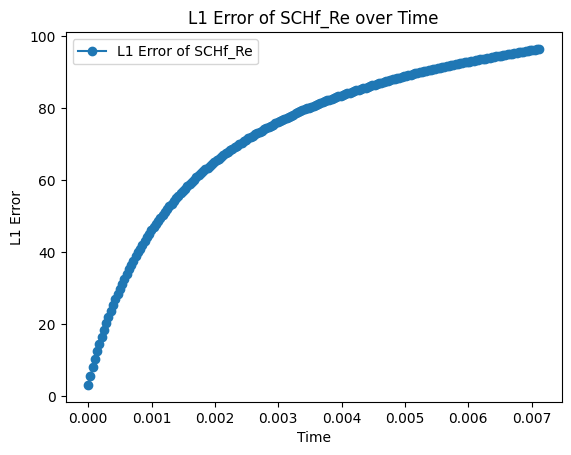

In [13]:
# Initialize an empty list to store the L1 errors
l1_errors = []

# Loop through each dataset and calculate the L1 error
for data in ds:
    ray, srt = extract_x_axis_arrays(data)
    x_sorted = np.array(ray["index", "x"][srt]) #TODO doesnt start at 0 
    y_sorted = np.array(ray['boxlib', 'SCHf_Re'][srt])
    
    # Calculate the analytical solution at the current time
    time = data.current_time.value
    analytic_re = SCH0 * np.cos(SCH_k * x_sorted - omega * time)
    
    # Calculate the L1 error
    l1_error = np.sum(np.abs(y_sorted - analytic_re)) / len(y_sorted)
    l1_errors.append(l1_error)

    index = 0
    if ds.index(data) == index:
        print("Time: ", time)
        print("x_sorted: ", x_sorted)
        print("Analytical SCHf_Re at x = 0: ", analytic_re)
        print("Numerical SCHf_Re at x = 0: ", y_sorted)
        continue

# Plot the L1 error over time
fig, ax = plt.subplots()
ax.plot(times, l1_errors, marker='o', linestyle='-', label="L1 Error of SCHf_Re")

# Add labels and title
ax.set_xlabel("Time")
ax.set_ylabel("L1 Error")
ax.set_title("L1 Error of SCHf_Re over Time")

# Add a legend
ax.legend()

# Show the plot
plt.show()

In [21]:
fig = plot.plots[("boxlib", "SCHf_Re")].figure

In [22]:
def animate(i):
    ts = ds[i]
    plot._switch_ds(ts)

In [23]:
animation = FuncAnimation(fig, animate, frames=len(ds))

In [24]:
import matplotlib.animation as animation

def create_animation(AMReXDataset, filename='animation.gif'):
    # Extract x-axis arrays
    ray, srt = extract_x_axis_arrays(AMReXDataset)
    x = np.array(ray["index", "x"][srt])
    y = np.array(ray['boxlib', 'SCHf_Re'][srt])

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Create a line object, initially empty
    line, = ax.plot(x, y)

    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=100, blit=True)

    # Save the animation
    ani.save(filename, writer='imagemagick')

# Example usage
create_animation(ds1)

NameError: name 'ds1' is not defined

In [25]:
# Override matplotlib's defaults to get a nicer looking font
with rc_context({"mathtext.fontset": "stix"}):
    #animation.save("animation.mp4")
    video = animation.to_html5_video()
    html = display.HTML(video)
    display.display(html)

AttributeError: module 'matplotlib.animation' has no attribute 'to_html5_video'

yt : [INFO     ] 2024-12-08 13:16:27,038 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-12-08 13:16:27,038 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2024-12-08 13:16:27,039 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-08 13:16:27,040 Parameters: domain_right_edge         = [1. 1. 1.]


yt : [WARNING  ] 2024-12-08 13:16:27,418 Field ('boxlib', 'SCHf_Re') already exists. To override use `force_override=True`.
yt : [INFO     ] 2024-12-08 13:16:27,451 Parameters: current_time              = 0.265303065215139
yt : [INFO     ] 2024-12-08 13:16:27,452 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2024-12-08 13:16:27,452 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-08 13:16:27,453 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [WARNING  ] 2024-12-08 13:16:27,546 Field ('boxlib', 'SCHf_Re') already exists. To override use `force_override=True`.
yt : [INFO     ] 2024-12-08 13:16:27,578 Parameters: current_time              = 0.530606130430277
yt : [INFO     ] 2024-12-08 13:16:27,578 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2024-12-08 13:16:27,579 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-08 13:16:27,580 Parameters: domain_right_edge         = [1. 1. 1.]
yt

AttributeError: 'LinePlot' object has no attribute '_colorbar_label'

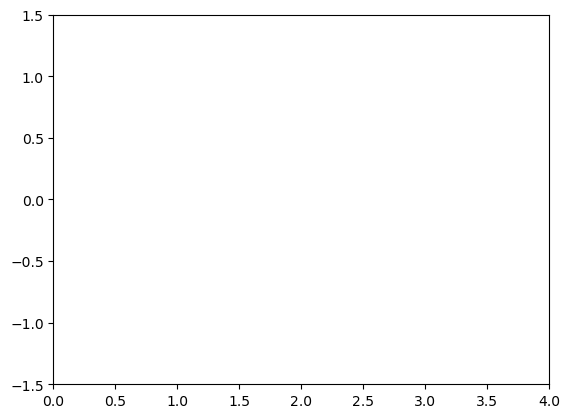

In [ ]:
import yt
import numpy as np
from yt.frontends.boxlib.api import AMReXDataset
from yt.data_objects.time_series import DatasetSeries
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc_context
from IPython.display import HTML

# Load the dataset series
path = "../Output/plt0????"
dsLoad = DatasetSeries(path, hint='amrex')

# Define custom field
def _relRef(field, data):
    av = data.ds.all_data().quantities.weighted_average_quantity(
        ("boxlib", "SCHf_Re"), weight=("index", "ones")
    )
    return data[("boxlib", "SCHf_Re")] / av

# Add custom field to datasets
for data in dsLoad:
    data.add_field(
        ("boxlib", "SCHf_Re"),
        function=_relRef,
        sampling_type="local",
        units="dimensionless"
    )

# Initialize LinePlot
plot = yt.LinePlot(
    dsLoad[0], ("boxlib", "SCHf_Re"), (0.0, 0.0, 0.0), (1.0, 0.0, 0.0), 1000
)
plot.set_log(("boxlib", "SCHf_Re"), False)
fig = plot.plots[("boxlib", "SCHf_Re")].figure

# Animation setup
axis = plt.axes(xlim=(0, 4), ylim=(-1.5, 1.5))
line, = axis.plot([], [], lw=3)

def animate(i):
    # Recreate the plot for each frame
    plot._switch_ds(dsLoad[i])
    line.set_data(plot.x, plot.y)
    line.set_color("green")
    return line,

animation = FuncAnimation(fig, animate, frames=len(dsLoad))

# Display animation
with rc_context({"mathtext.fontset": "stix"}):
    video = animation.to_html5_video()
    display(HTML(video))
